<a href="https://colab.research.google.com/github/ashwinij-7/Machine-Learning/blob/main/Random_Forest_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

100%|██████████| 26.4k/26.4k [00:00<00:00, 30.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prokshitha/home-value-insights/versions/1


In [15]:
import os
os.listdir(path)

['house_price_regression_dataset.csv']

In [17]:
import pandas as pd
df = pd.read_csv(os.path.join(path, 'house_price_regression_dataset.csv'))
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [18]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


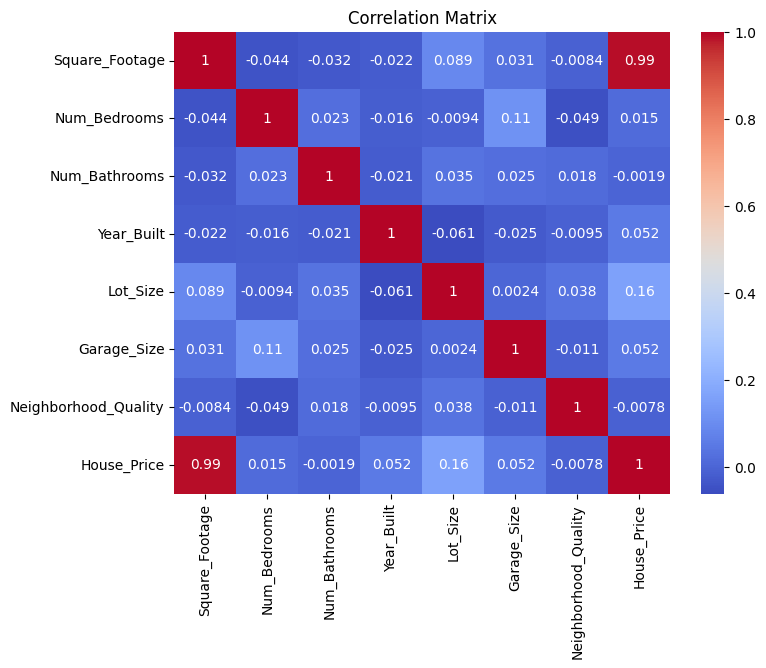

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
mean_squared_error = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

In [26]:
print("Mean Squared Error:", mean_squared_error)
print("R-squared Score:", r2_score)

Mean Squared Error: 394131747.44603425
R-squared Score: 0.9938855300068556


In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 19852.751634119493


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(scores)
print("Average R²:", scores.mean())

[0.99259542 0.99200212 0.99430301 0.99302374 0.99272877]
Average R²: 0.9929306114722841


In [27]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9989092102182057
Test R² : 0.9938855300068556
